In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sklearn & Machine Learning models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb

# Deep Learning libraries
import tensorflow as tf
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
# ==========================================
# 1. 评估模型并收集结果的函数
# ==========================================
def evaluate_and_collect(data):
    X = data.drop(columns=["stroke"])  
    y = data["stroke"]   

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 距离度量模型和神经网络需要标准化数据
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    results = {'accuracy': {}, 'importance': {}}

    # ---- 1. Logistic Regression ----
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
    lr_model.fit(X_train_scaled, y_train)
    results['accuracy']['LR'] = accuracy_score(y_test, lr_model.predict(X_test_scaled))
    results['importance']['LR'] = np.abs(lr_model.coef_[0])

    # ---- 2. Random Forest ----
    rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
    rf_model.fit(X_train, y_train)
    results['accuracy']['RF'] = accuracy_score(y_test, rf_model.predict(X_test))
    results['importance']['RF'] = rf_model.feature_importances_

    # ---- 3. XGBoost ----
    xgb_model = xgb.XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric="logloss")
    xgb_model.fit(X_train, y_train)
    results['accuracy']['XGB'] = accuracy_score(y_test, xgb_model.predict(X_test))
    results['importance']['XGB'] = xgb_model.feature_importances_

    # ---- 4. K-Nearest Neighbors (KNN) ----
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train_scaled, y_train)
    results['accuracy']['KNN'] = accuracy_score(y_test, knn_model.predict(X_test_scaled))
    results['importance']['KNN'] = None # KNN 没有特征重要性

    # ---- 5. Decision Tree ----
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train, y_train)
    results['accuracy']['DT'] = accuracy_score(y_test, dt_model.predict(X_test))
    results['importance']['DT'] = dt_model.feature_importances_

    # ---- 6. LightGBM ----
    lgb_model = lgb.LGBMClassifier(random_state=42, n_estimators=100)
    lgb_model.fit(X_train, y_train)
    results['accuracy']['LGBM'] = accuracy_score(y_test, lgb_model.predict(X_test))
    results['importance']['LGBM'] = lgb_model.feature_importances_

    # ---- 7. TensorFlow (Keras) ----
    tf.random.set_seed(42)
    tf_model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    tf_model.fit(X_train_scaled, y_train, epochs=30, batch_size=32, verbose=0)
    y_pred_tf = (tf_model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()
    results['accuracy']['TF'] = accuracy_score(y_test, y_pred_tf)
    results['importance']['TF'] = None # 简单NN不提取特征重要性

    # ---- 8. PyTorch ----
    torch.manual_seed(42)
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

    class SimpleNN(nn.Module):
        def __init__(self, input_dim):
            super(SimpleNN, self).__init__()
            self.fc1 = nn.Linear(input_dim, 16)
            self.relu = nn.ReLU()
            self.fc2 = nn.Linear(16, 8)
            self.fc3 = nn.Linear(8, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.relu(self.fc2(x))
            return self.sigmoid(self.fc3(x))

    pt_model = SimpleNN(X_train_scaled.shape[1])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(pt_model.parameters(), lr=0.01)

    for epoch in range(50):
        optimizer.zero_grad()
        outputs = pt_model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        y_pred_pt = (pt_model(X_test_t).numpy() > 0.5).astype(int).flatten()
    results['accuracy']['PyTorch'] = accuracy_score(y_test, y_pred_pt)
    results['importance']['PyTorch'] = None

    return results, X.columns

In [3]:
# ==========================================
# 2. 数据加载与预处理
# ==========================================
file_path = r"D:\Documents\dataset.csv"  
data = pd.read_csv(file_path)

if "id" in data.columns:  
    data = data.drop(columns=["id"])

data["smoking_status"] = data["smoking_status"].fillna("unknown")

categorical_features = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]
for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

# 准备三种数据集
data_drop = data.dropna(subset=["bmi"]).copy()

data_median = data.copy()
data_median["bmi"] = data_median["bmi"].fillna(data_median["bmi"].median())

data_knn = data.copy()
knn_imputer = KNNImputer(n_neighbors=5)
data_knn_imputed = knn_imputer.fit_transform(data_knn)
data_knn = pd.DataFrame(data_knn_imputed, columns=data_knn.columns)
data_knn["stroke"] = data_knn["stroke"].astype(int)

In [4]:
# ==========================================
# 3. 收集所有结果
# ==========================================
print("Training models and collecting results... (This may take a minute due to Neural Networks)")
res_drop, features = evaluate_and_collect(data_drop)
res_median, _ = evaluate_and_collect(data_median)
res_knn, _ = evaluate_and_collect(data_knn)

methods = ['Drop Missing', 'Median Fill', 'KNN Impute']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

Training models and collecting results... (This may take a minute due to Neural Networks)


d:\Apps\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:01:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 514, number of negative: 33036
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 33550, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.015320 -> initscore=-4.163130
[LightGBM] [Info] Start training from score -4.163130


d:\Apps\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Apps\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:01:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 626, number of negative: 34094
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 34720, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018030 -> initscore=-3.997526
[LightGBM] [Info] Start training from score -3.997526


d:\Apps\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Apps\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:02:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 626, number of negative: 34094
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 635
[LightGBM] [Info] Number of data points in the train set: 34720, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.018030 -> initscore=-3.997526
[LightGBM] [Info] Start training from score -3.997526


d:\Apps\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


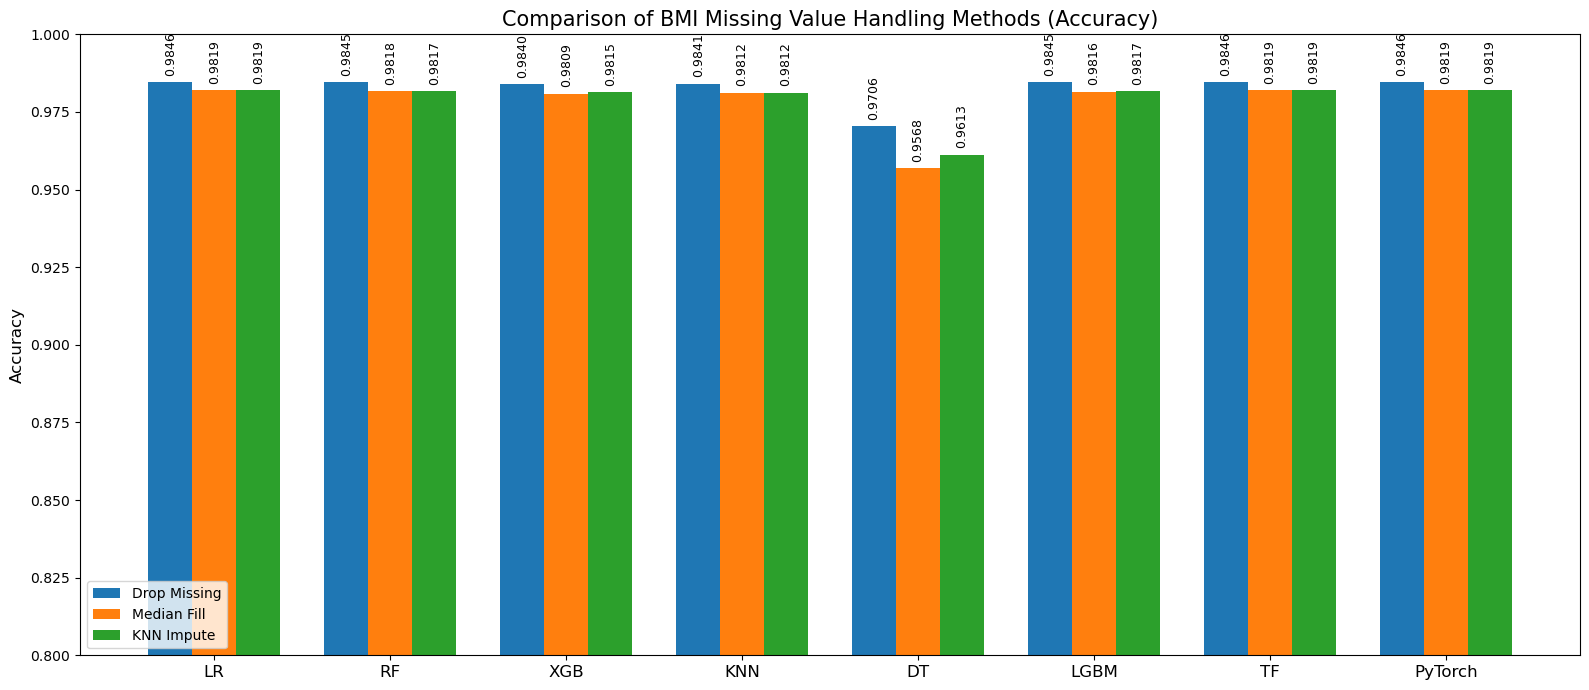

In [6]:
# ==========================================
# 4. 绘图：准确率对比 (包含所有 8 个模型)
# ==========================================
all_models = ['LR', 'RF', 'XGB', 'KNN', 'DT', 'LGBM', 'TF', 'PyTorch']
acc_drop = [res_drop['accuracy'][m] for m in all_models]
acc_median = [res_median['accuracy'][m] for m in all_models]
acc_knn = [res_knn['accuracy'][m] for m in all_models]

x = np.arange(len(all_models))
width = 0.25

plt.figure(figsize=(16, 7)) # 加宽画布以容纳更多模型
bars1 = plt.bar(x - width, acc_drop, width, label=methods[0], color=colors[0])
bars2 = plt.bar(x, acc_median, width, label=methods[1], color=colors[1])
bars3 = plt.bar(x + width, acc_knn, width, label=methods[2], color=colors[2])

plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparison of BMI Missing Value Handling Methods (Accuracy)', fontsize=15)
plt.xticks(x, all_models, fontsize=12)
plt.ylim(0.8, 1.0) 
plt.legend()

# 添加数值标签
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.4f}', ha='center', va='bottom', fontsize=9, rotation=90)

plt.tight_layout()
plt.show()

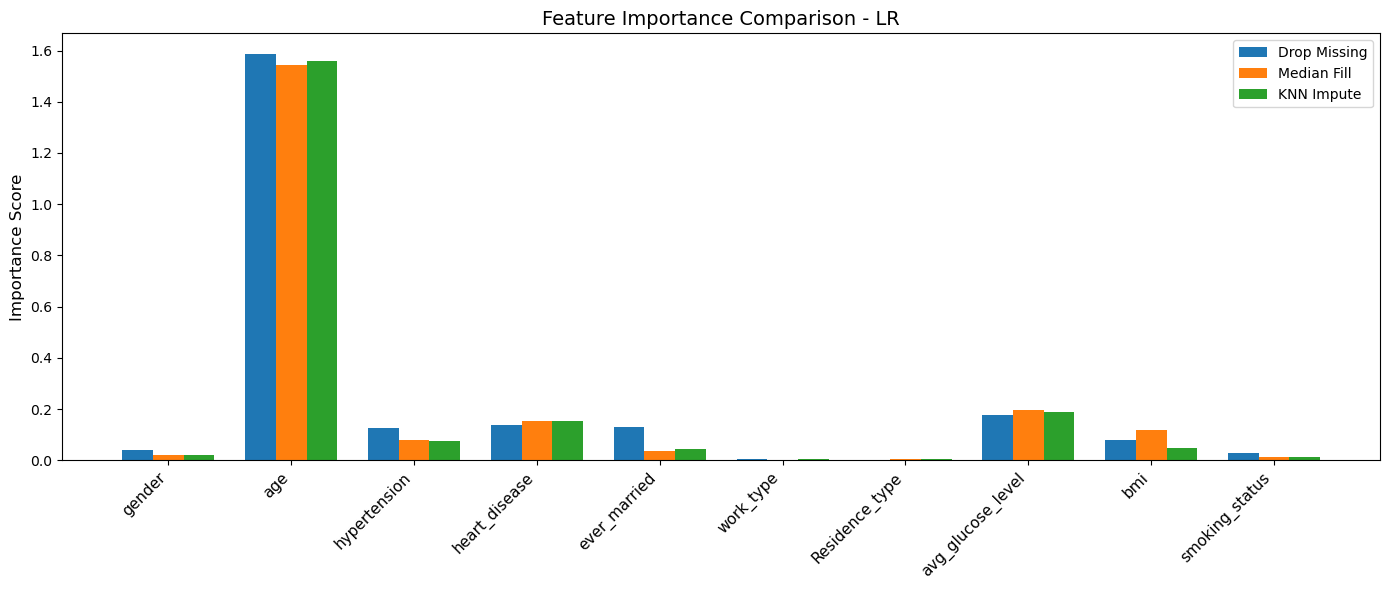

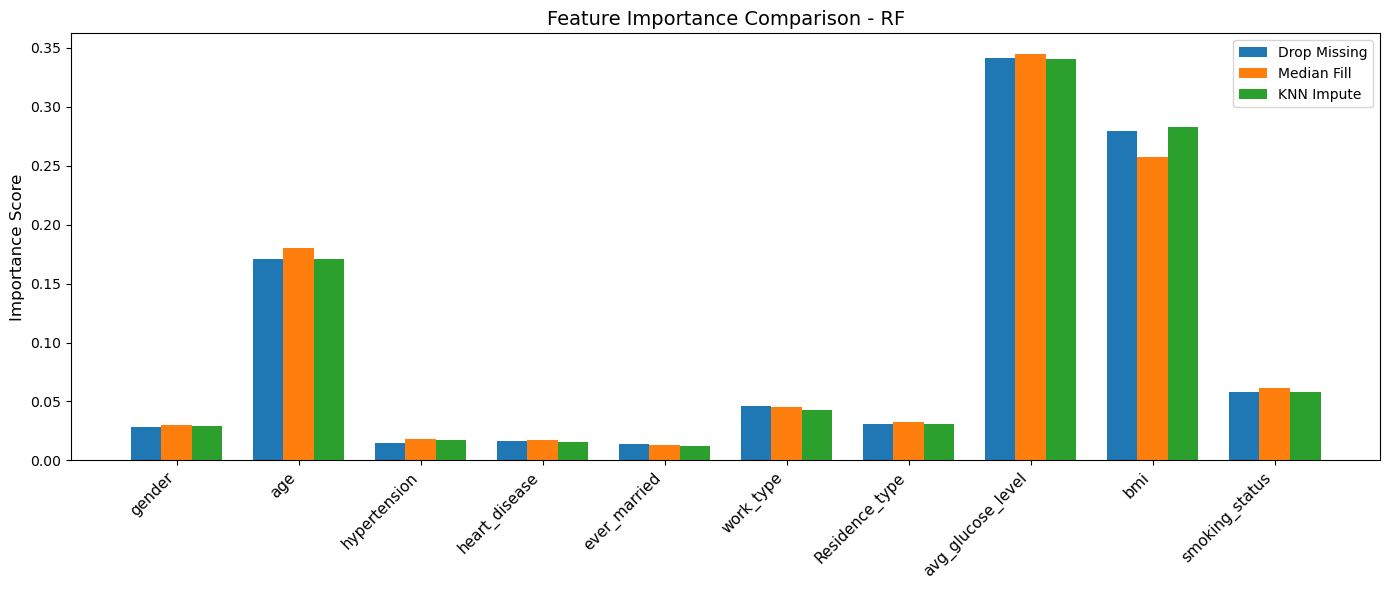

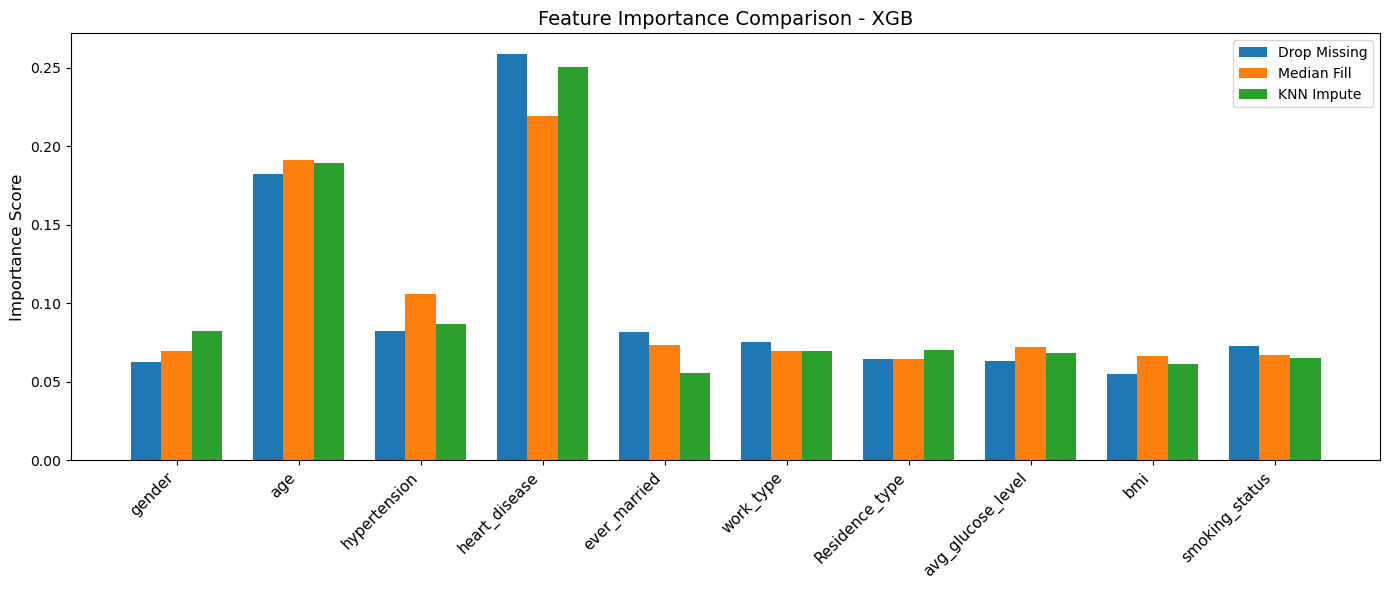

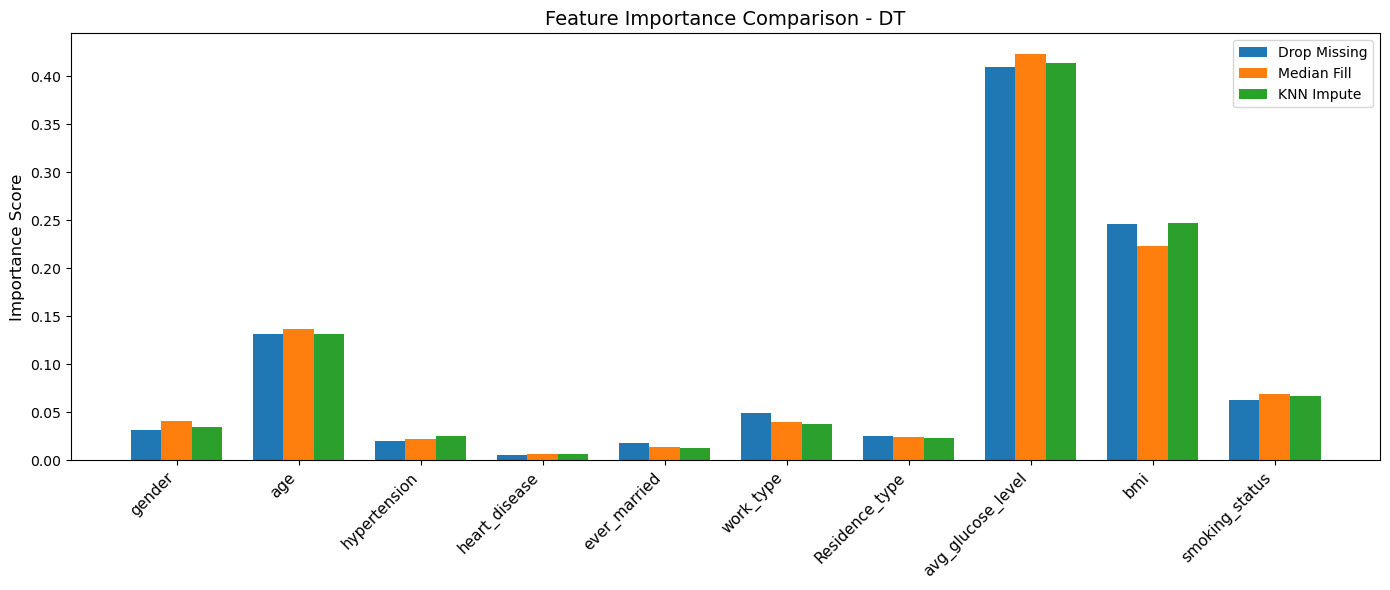

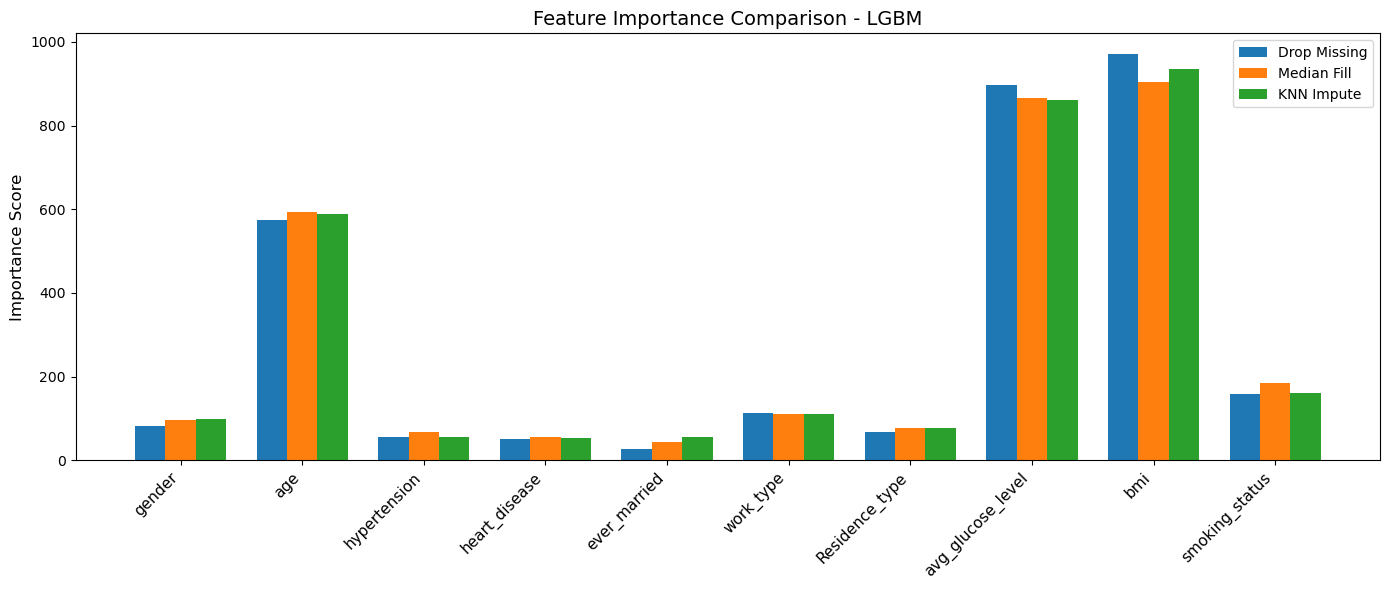

In [7]:
# ==========================================
# 5. 绘图：特征重要性对比 (仅限支持的模型)
# ==========================================
# 过滤掉没有特征重要性的模型 (KNN, TF, PyTorch)
importance_models = ['LR', 'RF', 'XGB', 'DT', 'LGBM']
x_feat = np.arange(len(features))

for model_name in importance_models:
    imp_drop = res_drop['importance'][model_name]
    imp_median = res_median['importance'][model_name]
    imp_knn = res_knn['importance'][model_name]
    
    plt.figure(figsize=(14, 6))
    plt.bar(x_feat - width, imp_drop, width, label=methods[0], color=colors[0])
    plt.bar(x_feat, imp_median, width, label=methods[1], color=colors[1])
    plt.bar(x_feat + width, imp_knn, width, label=methods[2], color=colors[2])
    
    plt.ylabel('Importance Score', fontsize=12)
    plt.title(f'Feature Importance Comparison - {model_name}', fontsize=14)
    plt.xticks(x_feat, features, rotation=45, ha='right', fontsize=11)
    plt.legend()
    plt.tight_layout()
    plt.show()